<center>
<h1>ISAT341-Data Science and Machine Learning
    </center>
    <center>
    <h2 style = "color:blue"> Lab 4- K-Nearest Neighbors Classification with Imported Data</h2>
</center>
    <img src="Images/machine-learning.jpg" width=200; height=200>
    <center>
    <h2>Classification with Imported Data (The Iris Flower Dataset)
    </center>

<center>
<h3>by Joshua Brewington
    <h3>
        </center>
    
<h3><u>Objectives
    </h3></u>
    
    - Create and use Machine Learning Models with SciKit Learn
    - Learn more advanced NumPy (Numerical Python) features
    - Learn how import data from remote websites (UCI Machine Learning Datasets)
    - Learn how to import and use SciKit Learn built-in datasets (iris flower dataset)
    - Train-test Split of data with SciKit Learn
    - Perform Classification with ScitKit Learn
    - Create Predictive Models
    - Perform Model Evaluation
        - Model Score and Accuracy
    - Decision Boundary Plotting with MatPlotLib

<h3><u>Introduction
    </h3></u>
    
The purpose of this lab goes over the concept of supervised learning. Supervised learning is the process of building classification models using data instances of known origins. Classificaiton is one of the more predominant strategies in data science and consists of three common characteristics. Learning is supervised, the dependent variable is categorical, and the emphasis is on building models able to assign new instances to one of a set of well-defined classes. The goal of this lab is to look at supervised learning through the scope of an Iris flower dataset, with the purpose of predicting a species with given measurements.

<img src="Images/iris.png" width=200; height=200>
    <center>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

This cell is importing the packages required to perform this lab. Matplotlib is used to create a plot.

In [2]:
# Load CSV using Pandas from URL
import pandas as pd
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
names = ['sepal_length','sepal_width','petal_length','petal_width','class']
iris_df = pd.read_csv(url, names=names)
iris_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


This cell loads in the iris flower data set from UCI Machine Learning Repository into a Pandas data frame. The last line of code is programmed to display the last 5 rows (observation) of the dataset with their respectives features present.

### Load and Examine the Data

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

This is importing the dataset from sklearn and setting it to a variable named "iris".

In [4]:
print('Keys of the iris dataset: \n{}'.format(iris.keys()))

Keys of the iris dataset: 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


This cell displays the keys that are part of the library extracted.

In [5]:
print('\n',iris['DESCR'][:475]+ '\n...')


 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Vi
...


This is displaying the description of the dataset.

In [6]:
# print the encoding scheme for species: 0 = setosa, 1 = versiclor, 2 = virginica
print('Target Names: {}'.format(iris.target_names))

print('Data Type: {}'.format(type(iris.target_names)))

Target Names: ['setosa' 'versicolor' 'virginica']
Data Type: <class 'numpy.ndarray'>


This is displaying the target names and their data types.

In [7]:
# print the name of the four features
print('Feature Names:\n {}'.format(iris.feature_names))

Feature Names:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


This displays the name of the features.

In [8]:
print('Shape of the data: {}'.format(iris.data.shape))

Shape of the data: (150, 4)


This is the shape of the data in rows and columns.

In [9]:
#print integers representing the species of each observation
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


These are the integeres for the species of each observation.

### Creating the Training and Testing Data to use with the Model

The imported data haas been loaded and it needs to be split into training and testing sets. We will use all four features for the respective datasets. The features will be stored in array called 'X' and the targets will be in a single column array 'y'.

In [10]:
# We use all 4 features of the dataset
X, y = iris.data[:, :4], iris.target
#print(x)
print('Class labels:', np.unique(y))
print('Class proportions:', np.bincount(y))

Class labels: [0 1 2]
Class proportions: [50 50 50]


### Test/train splits of data

We will use skitlearn to split the data into training and testing sets.

In [11]:
from sklearn.model_selection import train_test_split

# test_size=0.25 meand the test consists of 25% of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123,stratify=y)

print('Class labels of y_train:', np.unique(y_train))
print('Class proportions of y_train:',np.bincount(y_train))

Class labels of y_train: [0 1 2]
Class proportions of y_train: [35 35 35]


We used a larger testing size sample due to the size of the dataset and we set stratify = y to help proportion the dataset. We want labels to be split in train and test set as they are in the original dataset.

<center>
    <img src="Images/train_test_split.png" width=400; height=400>

Now the model can be trained and tested on different data. The response values are known for the testing set, and now predictions can be evaluated. Testing accuracy is a better estimate than the training accuracy for out-of-sample performance.

In [12]:
print('X_train Shape of the data : {}'.format(X_train.shape))
print('y_train Shape of the data : {}'.format(y_train.shape))

X_train Shape of the data : (105, 4)
y_train Shape of the data : (105,)


This displays the new shape of the trainingset.

In [13]:
print('X_test Shape of the data : {}'.format(X_test.shape))
print('y_test Shape of the data : {}'.format(y_test.shape))

X_test Shape of the data : (45, 4)
y_test Shape of the data : (45,)


This displays the new shape of the testingset.

## Creating a K-Nearest Neighbors Predictive Model (K=3)

### K-Nearest Neighbors Fit (K=3)

Import the KNN Classifier and let's also import the function to calculate some metrics.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
# pick 3-nearest neighbors
knn = KNeighborsClassifier(n_neighbors=3)

In [15]:
# print information on the model
print(knn)

KNeighborsClassifier(n_neighbors=3)


### Train the model

Here we fit(train) the KNN model to the training datasets.

In [16]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### Now that the model has been trained let's send it the test dataset to see what it predicts.

We will store the results of its predictions into a vector we call y_pred:

In [17]:
y_pred = knn.predict(X_test)

### We will print both the predictions and the actual values for visual inspection

In [18]:
print("Test set predictions:\n {}".format(y_pred))
print("Actual true values:\n {}".format(y_test))

Test set predictions:
 [2 2 1 1 2 0 0 1 0 0 2 0 2 0 1 0 2 2 0 0 0 0 0 1 0 1 2 0 1 2 2 2 2 1 1 1 2
 2 2 0 2 1 1 2 1]
Actual true values:
 [1 2 1 1 2 0 0 1 0 0 2 0 2 0 1 0 2 2 0 0 0 0 0 1 0 1 2 0 1 2 2 2 2 1 1 1 2
 1 2 0 2 1 1 2 1]


## Evaluating the K-nearest Neighbors Model

We can evaluate the model's performance in several ways. Two of the simplest ways are illustrated below.

1) First we will use the built-in scoring method. We will send the testing sets.

In [19]:
print('Test accuracy {0:0.2f}'.format(knn.score(X_test,y_test)))

Test accuracy 0.96


2) Next, we will use the SkitLearn metrics module's method of accuracy_score to compare.

In [20]:
# let's get the number of neighbors used and print the accuracy score
k=knn.n_neighbors
print("Model's Predictive Accuracy for k = {0} is: {1:0.2f} \n".format(k,metrics.accuracy_score(y_test,y_pred)))

Model's Predictive Accuracy for k = 3 is: 0.96 



Let's make a prediction using this model with new data. We will test it with the features of, sepal length=5cm, seppal width=2.9cm, petal length:cm, and petal width=0.2cm.

Let's put this data into a NumPy array.

In [21]:
# Reshaping an array
X_new = np.array([[5,2.9,1,0.2]])
print('X_new.shape is {}'.format(X_new.shape))

X_new.shape is (1, 4)


### To make a prediction let's again call the predict method of the K-Nearest Neighbors object:

In [22]:
prediction = knn.predict(X_new)
print("Prediction: {}".format(prediction))
print("Predicted Target Name: {}".format(iris['target_names'][prediction]))

Prediction: [0]
Predicted Target Name: ['setosa']


## Creating a K-NN Predictive Model for Multiple K's

### K-Nearest Neighbors fit for k = 1 and k = 5

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

for k in [1,5]:
    knn=KNeighborsClassifier(n_neighbors=k)
    print(knn)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)  
    print('Test accuracy (using knn.score()) for k = {0} is:{1:0.2f}'.format(k,knn.score(X_test,y_test)))
    print("Model's Predictive Accuracy for k = {0} is:{1:.2f}".format(k,metrics.accuracy_score(y_test,y_pred)))
    print('Misclassified samples for k = {0} are {1}\n'.format(k,(y_pred != y_test).sum()))

KNeighborsClassifier(n_neighbors=1)
Test accuracy (using knn.score()) for k = 1 is:0.96
Model's Predictive Accuracy for k = 1 is:0.96
Misclassified samples for k = 1 are 2

KNeighborsClassifier()
Test accuracy (using knn.score()) for k = 5 is:0.96
Model's Predictive Accuracy for k = 5 is:0.96
Misclassified samples for k = 5 are 2



## Exercises and Questions

k=1, Test accuracy: 0.96
k=2, Test accuracy: 0.96
k=3, Test accuracy: 0.96
k=4, Test accuracy: 0.96
k=5, Test accuracy: 0.96
k=6, Test accuracy: 0.93
k=7, Test accuracy: 0.96
k=8, Test accuracy: 0.98
k=9, Test accuracy: 0.96
k=10, Test accuracy: 0.98
k=11, Test accuracy: 0.98
k=12, Test accuracy: 0.98
k=13, Test accuracy: 0.96
k=14, Test accuracy: 0.93
k=15, Test accuracy: 0.96
k=16, Test accuracy: 0.96
k=17, Test accuracy: 0.98
k=18, Test accuracy: 0.98
k=19, Test accuracy: 0.96
k=20, Test accuracy: 0.96
k=21, Test accuracy: 0.96
k=22, Test accuracy: 0.96
k=23, Test accuracy: 0.96
k=24, Test accuracy: 0.96
k=25, Test accuracy: 0.93


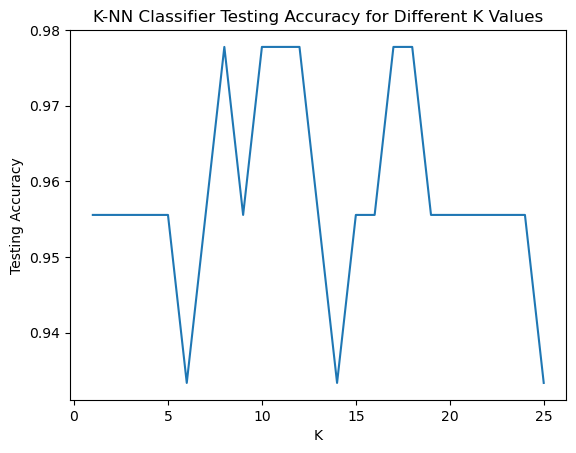

In [24]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1,26)
test_ac = []

for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    score=knn.score(X_test,y_test)
    test_ac.append(score)
    
    print(f'k={k}, Test accuracy: {score:.2f}')
    
plt.plot(k_values, test_ac)
plt.xlabel('K')
plt.ylabel('Testing Accuracy')
plt.title('K-NN Classifier Testing Accuracy for Different K Values')
plt.show()

### What would be possible ways to resolve ties in KNN when n_neighbors is an even number?
You could use majority voting with a different k-value, weight voting, random selection, or using a different metric.

### How do you break this tie in skitlearn?
I could use break_tiesbool, defualt=False. If it is true, the tie will break depending on the values of decision_function.